### E17: Standard OT to pair cells

**Started:** April 9, 2026

**Last updated:** April 10, 2026

**Research questions:** Can standard OT couple mouse and human cells in untransformed ortholog space?

**Hypothesis:** Standard OT will be able to couple oulier cell populations (e.g., non-immune in our data) but not immune populations, because non-immune populations cluster by cell type before species, whereas immune cells cluster by species before cell type.

**Conclusion:** Only 25% cell type pairing accuracy with standard OT on 500 cells (~18% when using all 6000 cells). Outlier cell types coupled well, but immune cells did not. Need a more advanced approach to cell coupling. Begs the question of whether neural OT will work in an autoencoder latent space with data from many cell types.

**Potential Next Steps:** Redo with latent space representations from scGen autoencoder.

In [71]:
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims, \
                                         knn_geodesic_distance_matrix
import ot
import sys
#sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse

In [2]:


plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

RESULTS = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8")
IMPACT_OR_DIR = RESULTS / "impact_or"
CELLOT_DIR = RESULTS / "cellot"

_cellot_data = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad")
_repo_data = RESULTS / "data.h5ad"
DATA_PATH = str(_cellot_data if _cellot_data.exists() else _repo_data)

HOLDOUT = "CL:0000625"
CT_COL = "cell_type_ontology_term_id"
SOURCE, TARGET = "mouse", "human"


def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)


print(f"Data path: {DATA_PATH}")
print("Setup complete.")

Data path: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad
Setup complete.


In [3]:
full_data = anndata.read_h5ad(DATA_PATH)
print(f"Full dataset: {full_data.shape}")
print(f"Obs columns: {list(full_data.obs.columns)}")
print(f"\nCell types:")
for ct_id, n in full_data.obs[CT_COL].value_counts().items():
    label = ""
    if 'cell_type' in full_data.obs.columns:
        match = full_data.obs.loc[full_data.obs[CT_COL] == ct_id, 'cell_type']
        if len(match) > 0:
            label = f" ({match.iloc[0]})"
    print(f"  {ct_id}{label}: {n} cells")

ref = full_data.copy()
ref.X = to_dense(ref.X).astype(np.float32)

print(f"\nComputing PCA (n_comps=30) ...")
sc.pp.pca(ref, n_comps=50)

print("Computing neighbors (n_neighbors=15, n_pcs=30) ...")
sc.pp.neighbors(ref, n_pcs=50, n_neighbors=15)

print("Computing UMAP (min_dist=0.3, random_state=42) ...")
sc.tl.umap(ref, min_dist=0.3, random_state=42)

print(f"\nReference UMAP done: {ref.obsm['X_umap'].shape}")

Full dataset: (12836, 1000)
Obs columns: ['condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id']

Cell types:
  CL:0008001 (hematopoietic precursor cell): 1584 cells
  CL:0000037 (hematopoietic stem cell): 1442 cells
  CL:0002393 (intermediate monocyte): 1008 cells
  CL:0000623 (natural killer cell): 912 cells
  CL:0000893 (thymocyte): 910 cells
  CL:0000875 (non-classical monocyte): 852 cells
  CL:1000320 (large intestine goblet cell): 760 cells
  CL:0002063 (pulmonary alveolar type 2 cell): 584 cells
  CL:0002543 (vein endothelial cell): 574 cells
  CL:0002548 (fibroblast of cardiac tissue): 484 cells
  CL:0002598 (bronchial smooth muscle cell): 440 cells
  CL:0000786 (plasma cell): 410 cells
  CL:0000236 (B cell): 406 cells
  CL:0000115 (endothelial cell): 406 cells
  CL:0000625 (CD8-positive, alpha-beta T cell): 390 cells
  CL:0000767 (basophil): 286 cells
  CL:0000084 (T cell): 204 cells
  CL:0000235 (macrophage): 204 cells
  CL:00

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing UMAP (min_dist=0.3, random_state=42) ...

Reference UMAP done: (12836, 2)


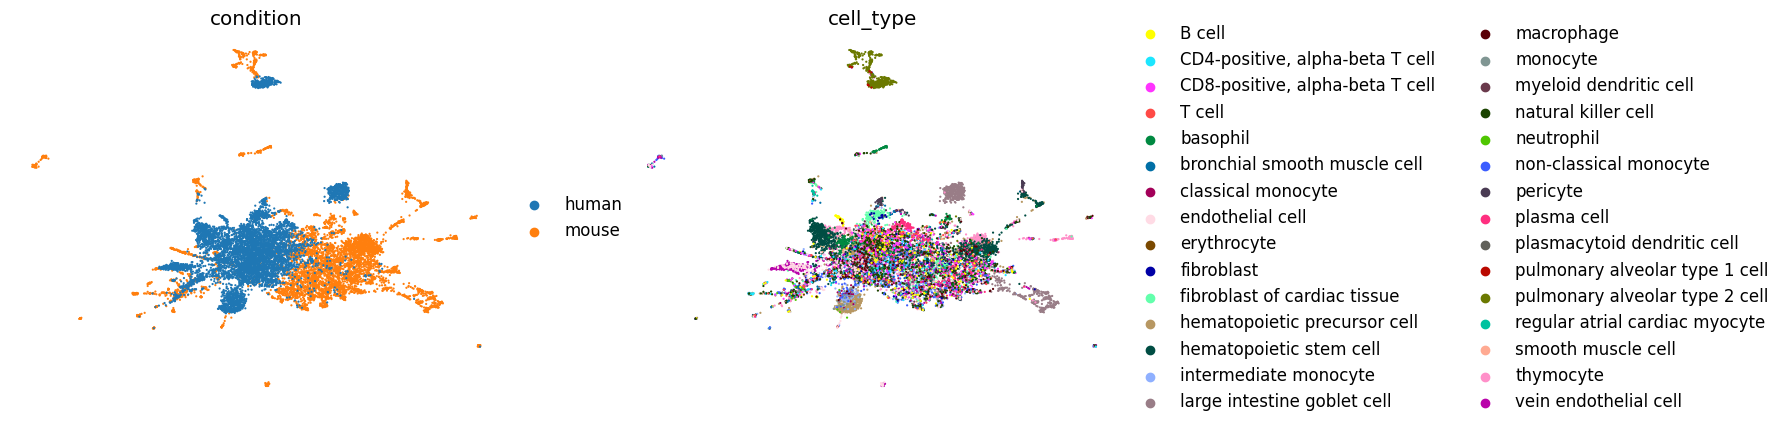

<Figure size 640x480 with 0 Axes>

In [4]:
sc.pl.umap(ref, color=['condition', 'cell_type'], frameon=False, s=10,
           ncols=2)
plt.tight_layout()
plt.show()

In [5]:
ref

AnnData object with n_obs × n_vars = 12836 × 1000
    obs: 'condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id'
    uns: 'pca', 'neighbors', 'umap', 'condition_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [11]:
len(adata_mouse)

6418

In [6]:
adata_mouse = ref[ref.obs['condition']=='mouse']
adata_human = ref[ref.obs['condition']=='human']

In [12]:
keep = np.random.permutation(np.concatenate([np.ones(500, dtype=int), np.zeros(len(adata_mouse)-500, dtype=int)]))

In [15]:
keep

array([0, 0, 0, ..., 0, 0, 0], shape=(6418,))

In [80]:
adata_mouse500 = adata_mouse[keep==1]
adata_human500 = adata_human[keep==1]

In [81]:
mouseX = adata_mouse500.obsm['X_pca']
humanX = adata_human500.obsm['X_pca']

In [82]:
num_cells = adata_mouse500.obsm['X_pca'].shape[0]

In [83]:
mouse_labels = adata_mouse500.obs['cell_type'].tolist()
human_labels = adata_human500.obs['cell_type'].tolist()

In [26]:
gw = run_ot(mouseX, humanX, num_cells, epsilon=0.1)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1206: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [27]:
compute_mapping_acc(gw, mouse_labels, human_labels)

0.186

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

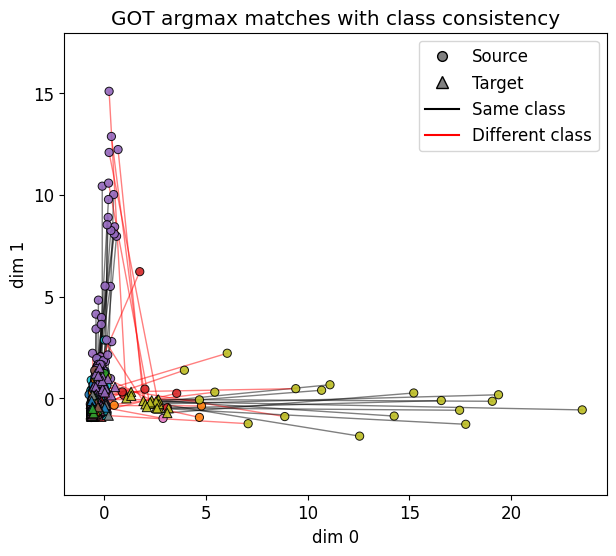

In [28]:
plot_got_best_matches_with_labels(mouseX, humanX, gw, mouse_labels, human_labels)

In [31]:
### Retry with geodesic distances (no anchors)
gw_human_geodesic = run_ot(mouseX, humanX, num_cells, epsilon=0.1, distance_method='geodesic', knn_k=10)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1206: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [32]:
compute_mapping_acc(gw_human_geodesic, mouse_labels, human_labels)

0.182

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

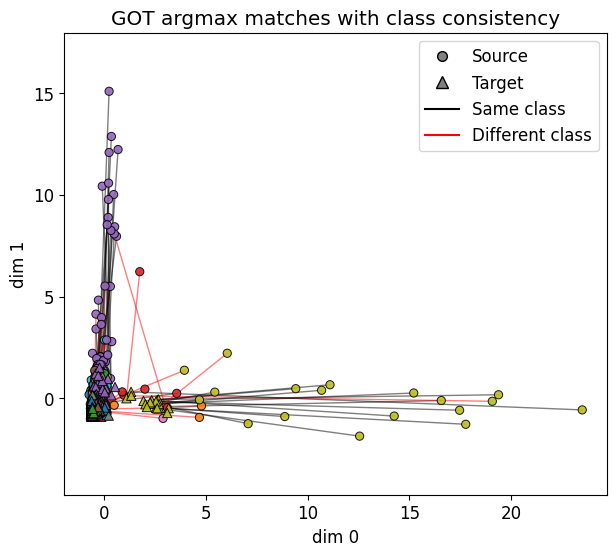

In [33]:
plot_got_best_matches_with_labels(mouseX, humanX, gw_human_geodesic, mouse_labels, human_labels)

Graph-based approach gets non-immune cells (outlier distributions) correct, largely fails with immune cells.

### Visualizing Euclidean results

In [36]:
tgt = np.asarray(human_labels)
target_pred_idx = np.argmax(gw, axis=1)   # length n_source
pred_target_labels = tgt[target_pred_idx]

In [39]:
adata_mouse500.obs['predictions'] = pred_target_labels
adata_human500.obs['predictions'] = adata_human500.obs['cell_type']

/tmp/ipykernel_2957984/1839776206.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mouse500.obs['predictions'] = pred_target_labels
/tmp/ipykernel_2957984/1839776206.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_human500.obs['predictions'] = adata_human500.obs['cell_type']


In [43]:
preds = anndata.concat([adata_mouse500, adata_human500], join="inner")

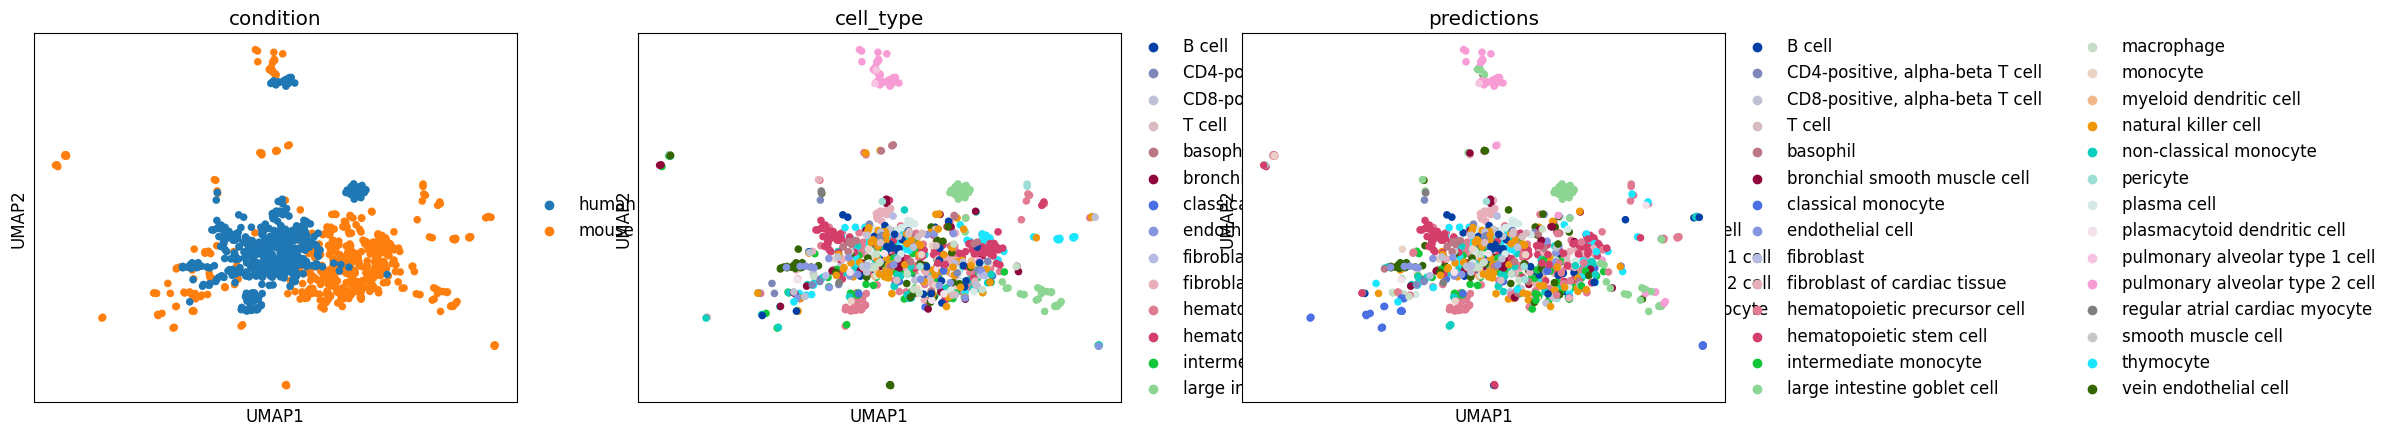

In [45]:
sc.pl.umap(preds, color=['condition','cell_type','predictions'])

### Visualizing Geodesic results

In [47]:
target_pred_idx = np.argmax(gw_human_geodesic, axis=1)   # length n_source
pred_target_labels = tgt[target_pred_idx]

In [48]:
adata_mouse500.obs['predictions_geodesic'] = pred_target_labels
adata_human500.obs['predictions_geodesic'] = adata_human500.obs['cell_type']

In [49]:
preds_geodesic = anndata.concat([adata_mouse500, adata_human500], join="inner")

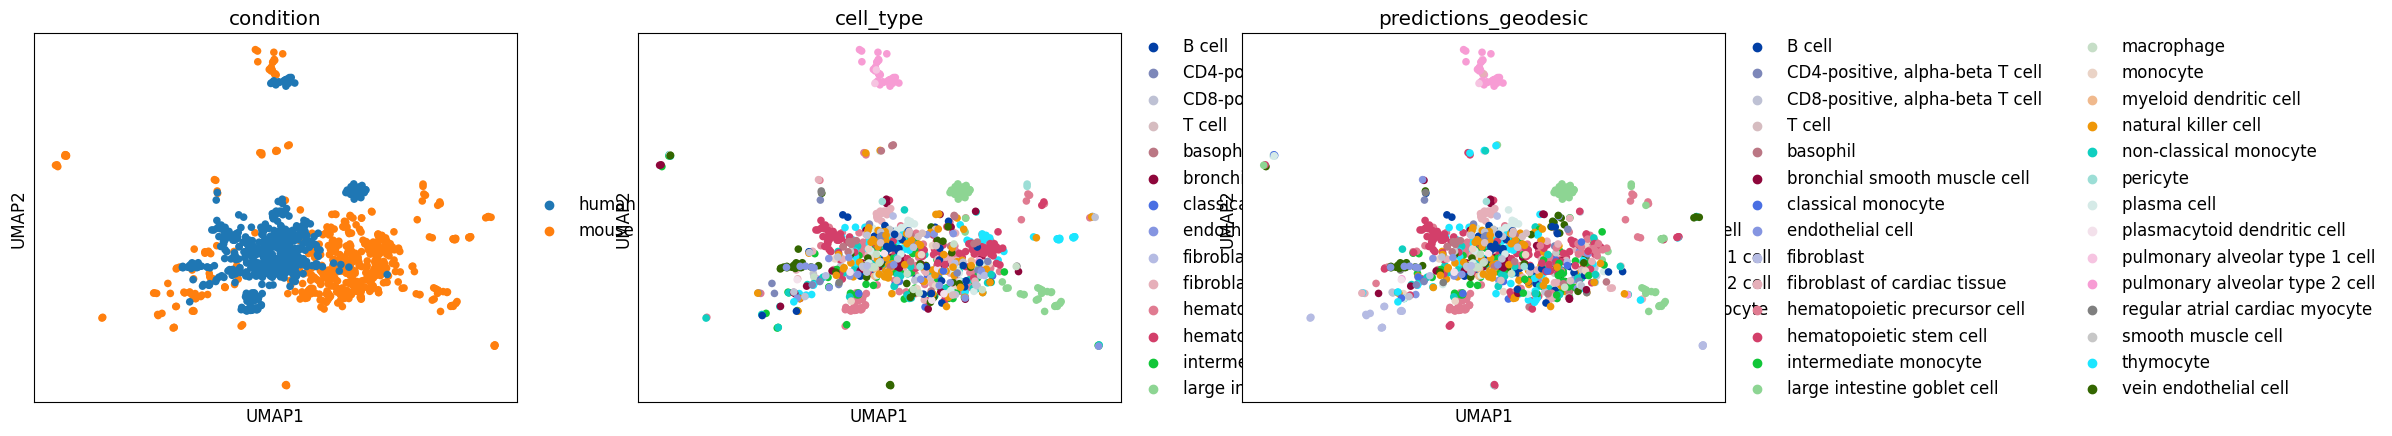

In [50]:
sc.pl.umap(preds_geodesic, color=['condition','cell_type','predictions_geodesic'])

Geodesic looks better, but I realized I don't need to use Gromov!

### Not using Gromov (EMD instead)

In [84]:
C = ot.dist(np.asarray(mouseX), np.asarray(humanX))
T = ot.emd(ot.unif(C.shape[0]), ot.unif(C.shape[1]), C)
# ot.sinkhorn(ot.unif(C.shape[0]), ot.unif(C.shape[1]), C, reg=1e-1)

In [85]:
compute_mapping_acc(T, mouse_labels, human_labels)

0.246

In [ ]:
# sinkhorn-regularized was only 0.16. non-regularized is better.

In [58]:
tgt = np.asarray(human_labels)
target_pred_idx = np.argmax(T, axis=1)   # length n_source
pred_target_labels = tgt[target_pred_idx]

In [59]:
adata_mouse500.obs['predictions_emd'] = pred_target_labels
adata_human500.obs['predictions_emd'] = adata_human500.obs['cell_type']

In [60]:
preds_emd = anndata.concat([adata_mouse500, adata_human500], join="inner")

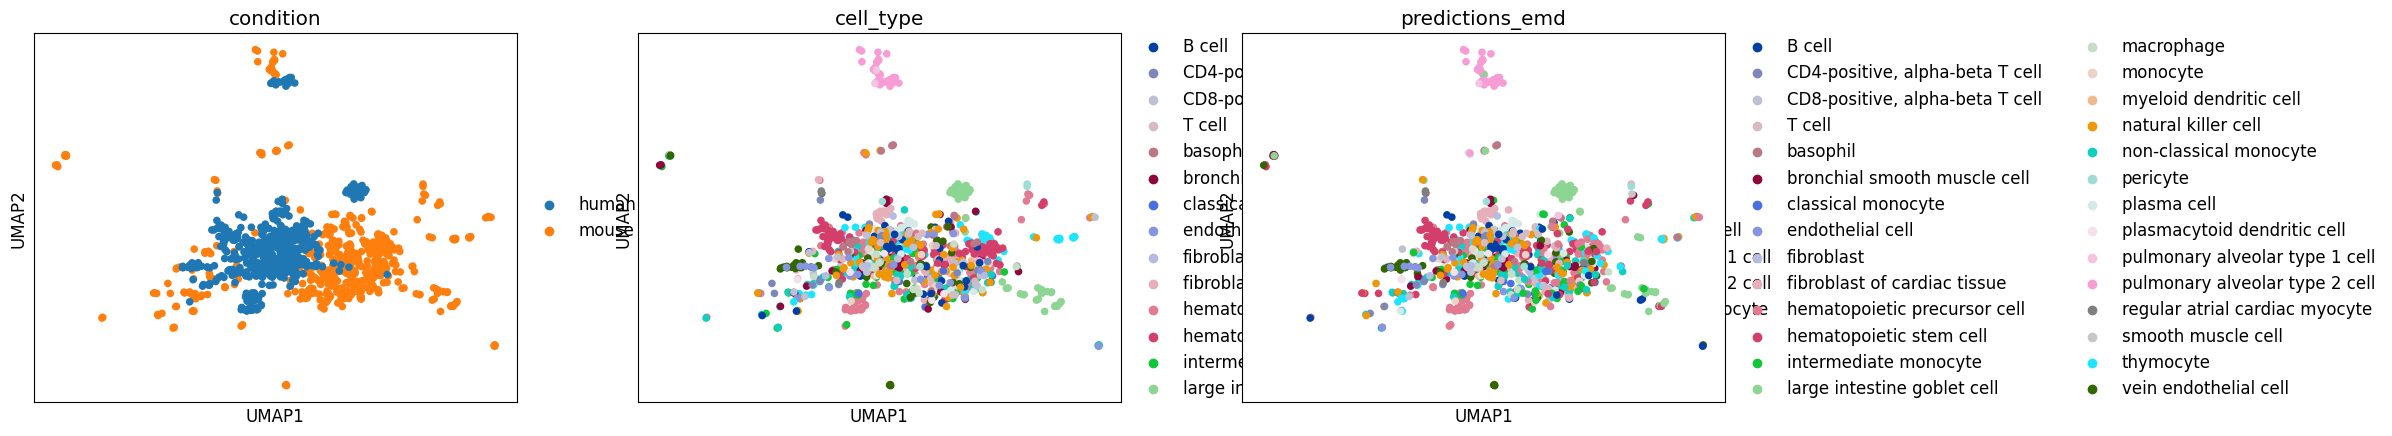

In [63]:
sc.pl.umap(preds_emd, color=['condition','cell_type','predictions_emd'])

Takeaway: standard OT cannot couple cell types effectively in shared ortholog space.